# Music Collection Overview — MusAV
**ACTSM Assignment 1 — Part 2**

Statistical report over 2,092 tracks analyzed with Essentia + CLAP.

In [1]:
import gzip
import pickle
import urllib.request
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid', palette='muted')
FEATURES_DIR = Path('../features')
OUTPUT_DIR = Path('output')
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'playlists').mkdir(parents=True, exist_ok=True)

## 1. Load features

In [2]:
files = sorted(FEATURES_DIR.rglob('*.pkl.gz'))
print(f'Total tracks: {len(files)}')

Total tracks: 2100


In [3]:
# Fetch Discogs400 genre labels
_META_URL = 'https://essentia.upf.edu/models/classification-heads/genre_discogs400/genre_discogs400-discogs-effnet-1.json'
with urllib.request.urlopen(_META_URL) as r:
    GENRE_LABELS = json.load(r)['classes']   # 400 strings: 'Genre---Style'
print(f'Genre labels: {len(GENRE_LABELS)}')
print(GENRE_LABELS[:5])

Genre labels: 400
['Blues---Boogie Woogie', 'Blues---Chicago Blues', 'Blues---Country Blues', 'Blues---Delta Blues', 'Blues---Electric Blues']


In [4]:
records = []
genre_activations = []

for fpath in tqdm(files, desc='Loading features'):
    track_id = fpath.stem.replace('.pkl', '')
    try:
        with gzip.open(fpath, 'rb') as f:
            d = pickle.load(f)
    except Exception:
        continue

    # top genre by max activation
    genre_vec = d['genre_discogs400']
    top_idx = int(np.argmax(genre_vec))
    top_label = GENRE_LABELS[top_idx]
    parent_genre, style = top_label.split('---', 1)

    records.append({
        'track_id': track_id,
        'bpm': d['bpm'],
        'bpm_confidence': d['bpm_confidence'],
        'key_temperley': d['key_temperley']['key'] + ' ' + d['key_temperley']['scale'],
        'key_krumhansl': d['key_krumhansl']['key'] + ' ' + d['key_krumhansl']['scale'],
        'key_edma': d['key_edma']['key'] + ' ' + d['key_edma']['scale'],
        'key_conf_temperley': d['key_temperley']['confidence'],
        'key_conf_krumhansl': d['key_krumhansl']['confidence'],
        'key_conf_edma': d['key_edma']['confidence'],
        'loudness_lufs': d['loudness_integrated_lufs'],
        'voice_prob': float(d['voice_instrumental'][0]),
        'instrumental_prob': float(d['voice_instrumental'][1]),
        'danceability_prob': float(d['danceability'][1]),
        'top_style': top_label,
        'parent_genre': parent_genre,
    })
    genre_activations.append(genre_vec)

df = pd.DataFrame(records)
genre_matrix = np.stack(genre_activations)   # (N, 400)
print(f'Loaded: {len(df)} tracks')
df.head(3)

Loading features:   0%|          | 0/2100 [00:00<?, ?it/s]

Loaded: 2100 tracks


,track_id,bpm,bpm_confidence,key_temperley,key_krumhansl,key_edma,key_conf_temperley,key_conf_krumhansl,key_conf_edma,loudness_lufs,voice_prob,instrumental_prob,danceability_prob,top_style,parent_genre
0,02KPo7DqVnSTSZnKvdT5NU,78.305321,3.606108,D major,D major,D major,0.728812,0.839963,0.860044,-16.380695,0.057322,0.942678,0.916701,Pop---Ballad,Pop
1,02dMF381tQaidG17In1Tt2,122.541878,3.691259,C# major,Bb minor,Bb minor,0.700429,0.781342,0.876777,-10.924894,0.081810,0.918190,0.752477,Funk / Soul---Soul,Funk / Soul
2,03YAkNt5ctr4vQwqmNPybe,112.243500,3.855619,Bb minor,Bb minor,Bb minor,0.591008,0.570086,0.482536,-8.444010,0.292613,0.707387,0.002417,Electronic---Dubstep,Electronic


## 2. Music Styles

### 2a. Parent genre distribution (max-activation rule)

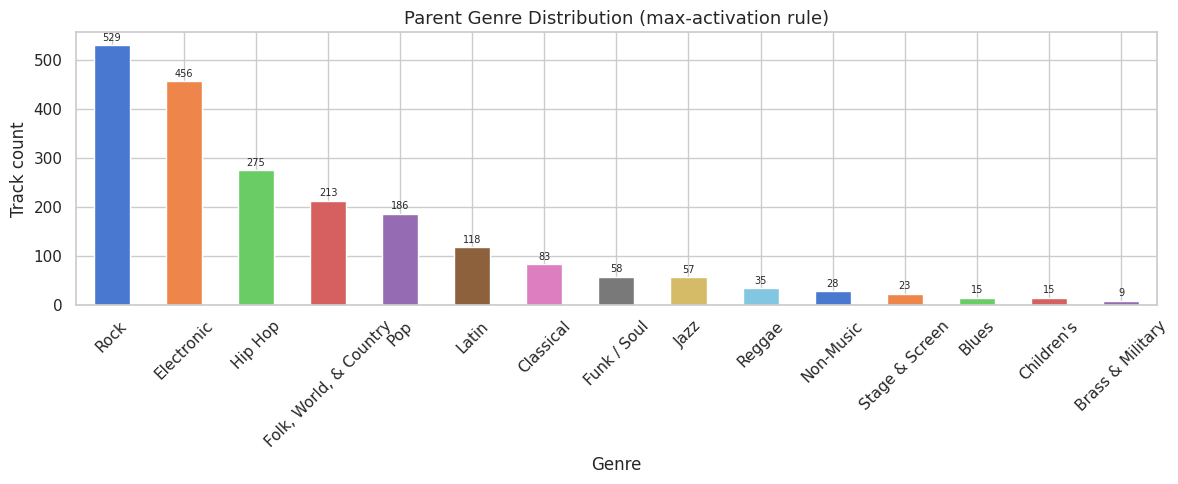

In [5]:
genre_counts = df['parent_genre'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(genre_counts)))
ax.set_title('Parent Genre Distribution (max-activation rule)', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Track count')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'genre_parent_distribution.png', dpi=150)
plt.show()

### 2b. Full style TSV

In [6]:
style_counts = df['top_style'].value_counts().reset_index()
style_counts.columns = ['style', 'count']
style_counts['percentage'] = (style_counts['count'] / len(df) * 100).round(2)
style_counts.insert(0, 'parent_genre', style_counts['style'].str.split('---').str[0])

tsv_path = OUTPUT_DIR / 'style_distribution.tsv'
style_counts.to_csv(tsv_path, sep='\t', index=False)
print(f'Saved: {tsv_path}')
style_counts.head(20)

Saved: output/style_distribution.tsv


,parent_genre,style,count,percentage
0,"Folk, World, & Country","Folk, World, & Country---Folk",83,3.95
1,Rock,Rock---Alternative Rock,74,3.52
2,Rock,Rock---Punk,68,3.24
3,Electronic,Electronic---House,65,3.10
4,Hip Hop,Hip Hop---Trap,60,2.86
5,Rock,Rock---Pop Rock,57,2.71
6,Electronic,Electronic---Ambient,56,2.67
7,Pop,Pop---Ballad,55,2.62
8,Hip Hop,Hip Hop---Cloud Rap,54,2.57
9,Pop,Pop---K-pop,46,2.19


### 2c. Multi-label view (activation threshold = 0.1)

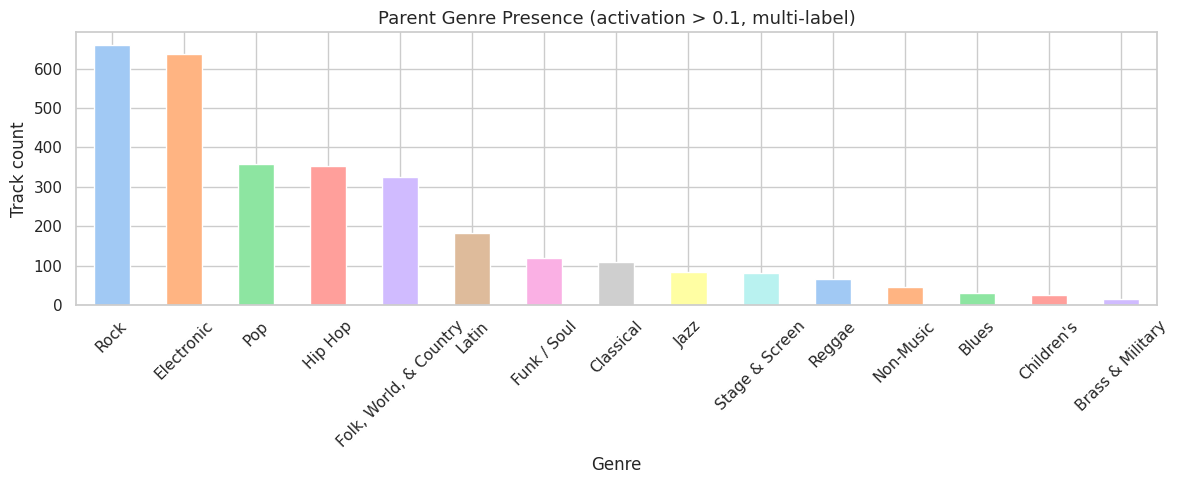

In [7]:
THRESHOLD = 0.1
parent_labels = [l.split('---')[0] for l in GENRE_LABELS]

# For each parent genre, fraction of tracks with at least one style > threshold
parent_genres_unique = sorted(set(parent_labels))
multi_counts = {}
for pg in parent_genres_unique:
    idxs = [i for i, l in enumerate(parent_labels) if l == pg]
    presence = (genre_matrix[:, idxs] > THRESHOLD).any(axis=1)
    multi_counts[pg] = presence.sum()

multi_series = pd.Series(multi_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
multi_series.plot(kind='bar', ax=ax, color=sns.color_palette('pastel', len(multi_series)))
ax.set_title(f'Parent Genre Presence (activation > {THRESHOLD}, multi-label)', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Track count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'genre_parent_multilabel.png', dpi=150)
plt.show()

## 3. Tempo and Danceability

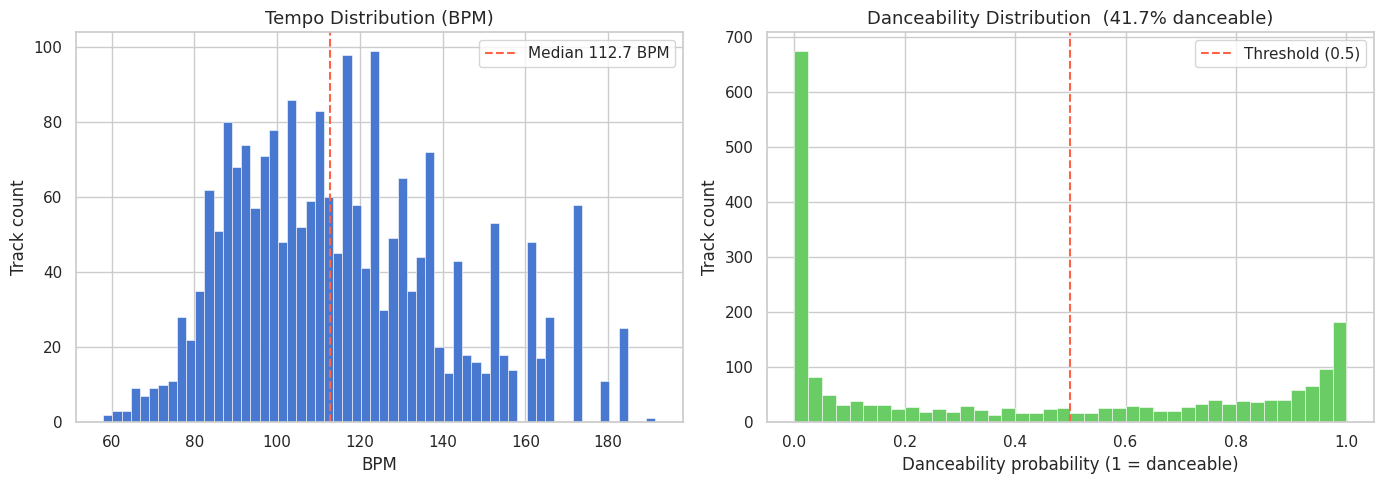

           bpm  danceability_prob
count  2100.00            2100.00
mean    116.17               0.41
std      26.51               0.39
min      57.94               0.00
25%      95.59               0.01
50%     112.67               0.29
75%     132.87               0.82
max     191.41               1.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BPM histogram
ax = axes[0]
ax.hist(df['bpm'], bins=60, color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.4)
ax.axvline(df['bpm'].median(), color='tomato', linestyle='--', label=f"Median {df['bpm'].median():.1f} BPM")
ax.set_title('Tempo Distribution (BPM)', fontsize=13)
ax.set_xlabel('BPM')
ax.set_ylabel('Track count')
ax.legend()

# Danceability histogram
ax = axes[1]
ax.hist(df['danceability_prob'], bins=40, color=sns.color_palette('muted')[2], edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='tomato', linestyle='--', label='Threshold (0.5)')
danceable_pct = (df['danceability_prob'] >= 0.5).mean() * 100
ax.set_title(f'Danceability Distribution  ({danceable_pct:.1f}% danceable)', fontsize=13)
ax.set_xlabel('Danceability probability (1 = danceable)')
ax.set_ylabel('Track count')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'tempo_danceability.png', dpi=150)
plt.show()

print(df[['bpm', 'danceability_prob']].describe().round(2))

## 4. Key and Scale

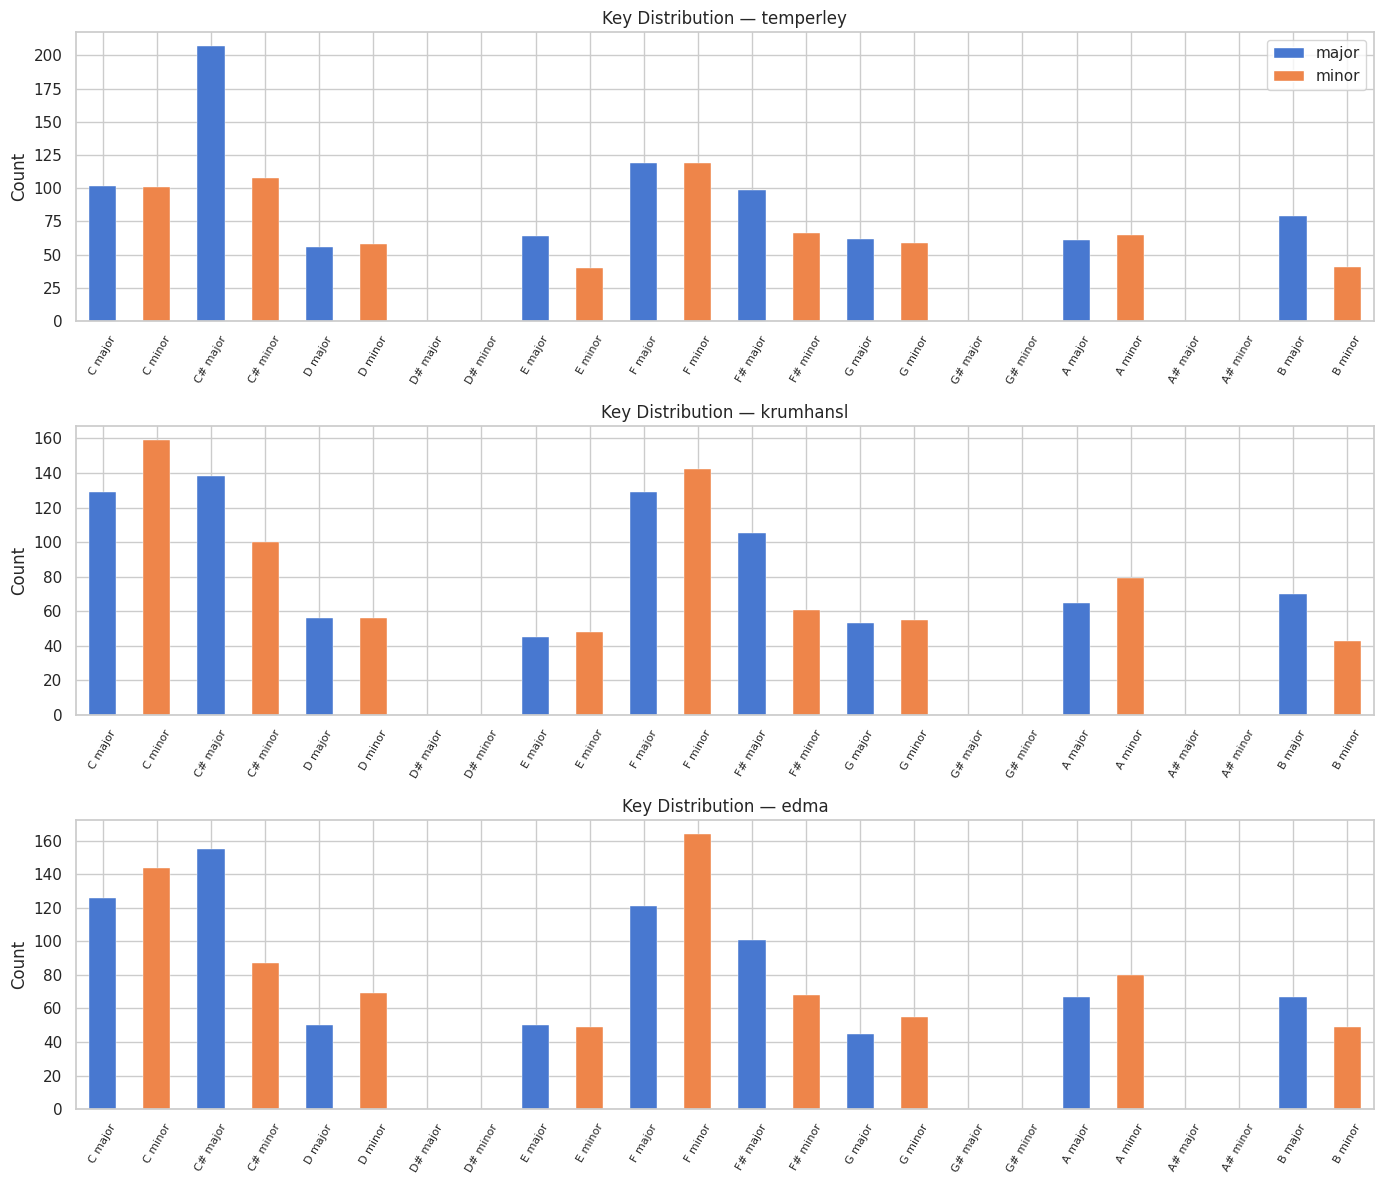

In [9]:
KEY_ORDER = ['C major','C minor','C# major','C# minor',
             'D major','D minor','D# major','D# minor',
             'E major','E minor','F major','F minor',
             'F# major','F# minor','G major','G minor',
             'G# major','G# minor','A major','A minor',
             'A# major','A# minor','B major','B minor']

profiles = ['temperley', 'krumhansl', 'edma']
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, profile in zip(axes, profiles):
    col = f'key_{profile}'
    counts = df[col].value_counts().reindex(KEY_ORDER, fill_value=0)
    colors = ['#4878d0' if 'major' in k else '#ee854a' for k in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_title(f'Key Distribution — {profile}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60, labelsize=8)

# shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4878d0', label='major'), Patch(facecolor='#ee854a', label='minor')]
axes[0].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'key_distribution.png', dpi=150)
plt.show()

In [10]:
# Agreement between profiles
all_agree = (df['key_temperley'] == df['key_krumhansl']) & \
            (df['key_krumhansl'] == df['key_edma'])
agree_pct = all_agree.mean() * 100
print(f'Tracks where all 3 profiles agree: {all_agree.sum()} / {len(df)} ({agree_pct:.1f}%)')

# Pairwise
for a, b in [('temperley','krumhansl'), ('temperley','edma'), ('krumhansl','edma')]:
    pct = (df[f'key_{a}'] == df[f'key_{b}']).mean() * 100
    print(f'  {a} == {b}: {pct:.1f}%')

Tracks where all 3 profiles agree: 943 / 2100 (44.9%)
  temperley == krumhansl: 55.2%
  temperley == edma: 49.9%
  krumhansl == edma: 76.3%


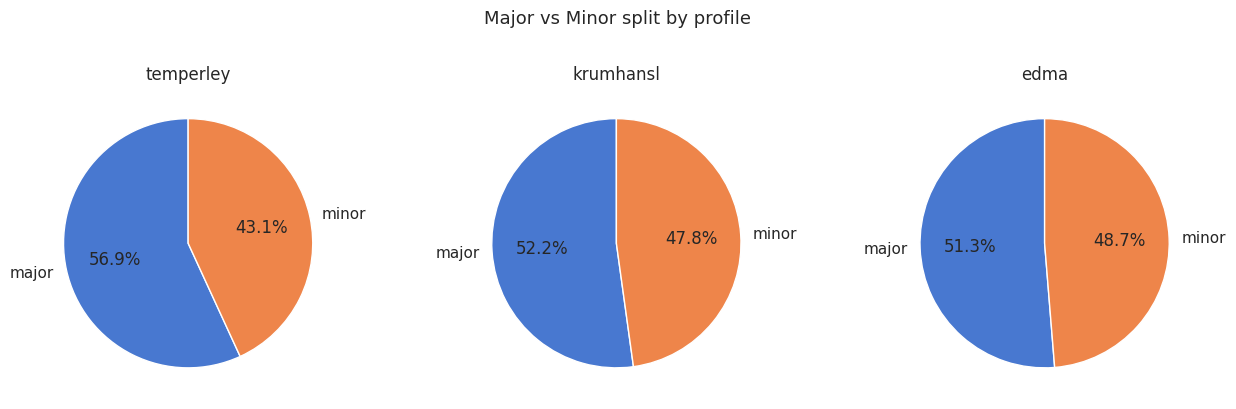

In [11]:
# Scale (major/minor) split per profile
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, profile in zip(axes, profiles):
    col = f'key_{profile}'
    scales = df[col].str.split(' ').str[-1].value_counts()
    ax.pie(scales, labels=scales.index, autopct='%1.1f%%',
           colors=['#4878d0', '#ee854a'], startangle=90)
    ax.set_title(f'{profile}', fontsize=12)
plt.suptitle('Major vs Minor split by profile', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'key_scale_split.png', dpi=150, bbox_inches='tight')
plt.show()

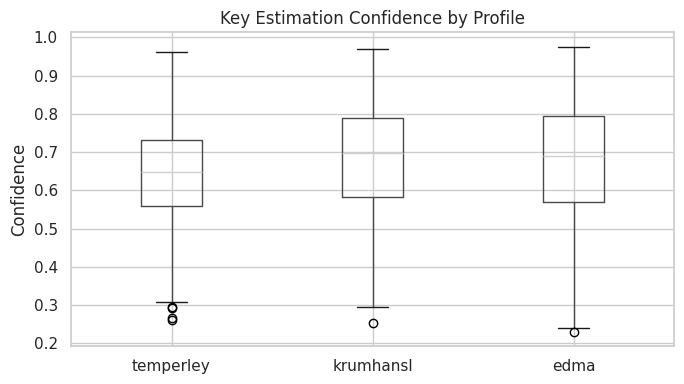

       temperley  krumhansl      edma
count   2100.000   2100.000  2100.000
mean       0.642      0.681     0.674
std        0.123      0.137     0.147
min        0.261      0.253     0.231
25%        0.558      0.584     0.569
50%        0.647      0.697     0.691
75%        0.731      0.788     0.794
max        0.961      0.969     0.976


In [12]:
# Key confidence boxplot
conf_df = pd.DataFrame({
    'temperley': df['key_conf_temperley'],
    'krumhansl': df['key_conf_krumhansl'],
    'edma': df['key_conf_edma'],
})
fig, ax = plt.subplots(figsize=(7, 4))
conf_df.boxplot(ax=ax)
ax.set_title('Key Estimation Confidence by Profile')
ax.set_ylabel('Confidence')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'key_confidence.png', dpi=150)
plt.show()
print(conf_df.describe().round(3))

## 5. Loudness

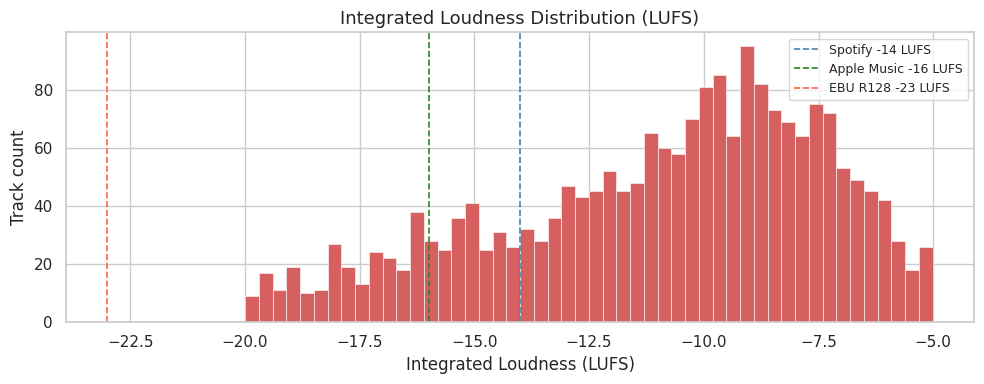

count    2100.00
mean      -10.97
std         3.55
min       -20.00
25%       -13.27
50%       -10.22
75%        -8.27
max        -5.01
Name: loudness_lufs, dtype: float64


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['loudness_lufs'], bins=50, color=sns.color_palette('muted')[3], edgecolor='white', linewidth=0.4)

# Reference lines per platform target
for lufs, label, color in [(-14, 'Spotify -14 LUFS', 'steelblue'),
                            (-16, 'Apple Music -16 LUFS', 'forestgreen'),
                            (-23, 'EBU R128 -23 LUFS', 'tomato')]:
    ax.axvline(lufs, linestyle='--', color=color, linewidth=1.2, label=label)

ax.set_title('Integrated Loudness Distribution (LUFS)', fontsize=13)
ax.set_xlabel('Integrated Loudness (LUFS)')
ax.set_ylabel('Track count')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'loudness_distribution.png', dpi=150)
plt.show()

print(df['loudness_lufs'].describe().round(2))

## 6. Vocal vs Instrumental

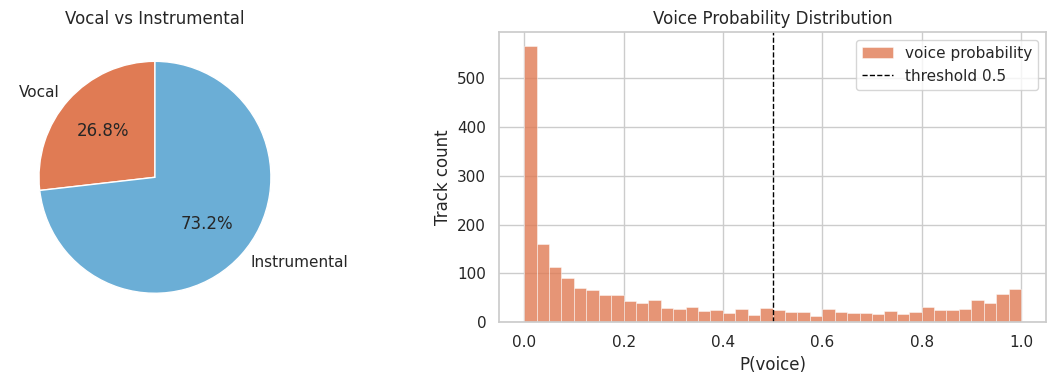

Vocal:        563 (26.8%)
Instrumental: 1537 (73.2%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie: vocal vs instrumental (threshold 0.5)
ax = axes[0]
vocal = (df['voice_prob'] >= 0.5).sum()
instrumental = len(df) - vocal
ax.pie([vocal, instrumental], labels=['Vocal', 'Instrumental'],
       autopct='%1.1f%%', colors=['#e07b54', '#6baed6'], startangle=90)
ax.set_title('Vocal vs Instrumental', fontsize=12)

# Distribution of vocal probability
ax = axes[1]
ax.hist(df['voice_prob'], bins=40, color='#e07b54', edgecolor='white', linewidth=0.4, alpha=0.8, label='voice probability')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold 0.5')
ax.set_title('Voice Probability Distribution', fontsize=12)
ax.set_xlabel('P(voice)')
ax.set_ylabel('Track count')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'voice_instrumental.png', dpi=150)
plt.show()

print(f'Vocal:        {vocal} ({vocal/len(df)*100:.1f}%)')
print(f'Instrumental: {instrumental} ({instrumental/len(df)*100:.1f}%)')

## 7. Observations and Discussion

### Music Style Diversity
MusAV is stylistically diverse. Under the max-activation rule the top individual styles are Folk---Folk (3.95%), Rock---Alternative Rock (3.52%), Rock---Punk (3.24%), Electronic---House (3.10%), and Hip Hop---Trap (2.86%). Aggregated to parent genres, **Rock** is the dominant category (Alternative Rock + Punk + Pop Rock + Indie Rock + Metal + Hard Rock alone exceed 300 tracks), followed by Electronic and Hip Hop. No single style exceeds 4% of the collection, indicating broad coverage rather than genre monoculture. The multi-label view (threshold = 0.1) further confirms that many tracks carry meaningful secondary genre signals. The full 400-style breakdown is saved to `output/style_distribution.tsv`.

### Tempo and Danceability
BPM spans 58–191 (median 112.7, mean 116.2, std 26.5), covering slow ballads through fast electronic music. The distribution is broad and roughly unimodal around 90–130 BPM, the dominant tempo range for contemporary popular music. Danceability is bimodal with a median of only 0.29 but a 75th percentile of 0.82: most tracks are strongly non-danceable or strongly danceable with few in between, suggesting the model is confident in its classifications. Only **41.7%** of tracks score ≥ 0.5, so the collection leans non-danceable overall — consistent with a wide-genre corpus that includes classical, ambient, and folk material.

### Key and Scale — Profile Comparison
All three profiles produce plausible key distributions dominated by common Western tonalities (C, G, D, A major/minor). However, they disagree substantially: all three agree on only **44.9%** of tracks. Pairwise agreement is higher between `krumhansl` and `edma` (76.3%) than between `temperley` and either of the other two (55.2% and 49.9% respectively), revealing that `temperley` is the systematic outlier.

Confidence scores are similar across profiles (median ≈ 0.65–0.70), but `krumhansl` and `edma` are marginally more confident and far more consistent with each other. **For a single-profile presentation to users, `edma` is the recommended choice**: it has the highest median confidence (0.691 vs 0.647 for temperley) and is part of the most coherent pair (krumhansl–edma at 76.3% agreement). The high krumhansl–edma agreement also suggests these two profiles model the same underlying tonal perception, while `temperley` captures a distinctly different interpretation.

### Loudness
The loudness distribution is centered around **−10.2 LUFS** (median), mean −11.0 LUFS, std 3.55, range −20 to −5 LUFS. This is **significantly louder** than both Spotify's target (−14 LUFS) and the EBU R128 broadcast standard (−23 LUFS). Only a small tail of tracks fall below −16 LUFS; those are likely classical or acoustic recordings. The hottest tracks approach −5 LUFS — the upper edge before perceptible clipping artifacts appear. This pattern is consistent with the "loudness war": streaming preview clips are often sourced from commercially mastered releases where loudness maximisation is common. Platforms normalise at playback time, so these LUFS values reflect raw master levels, not perceived loudness to the end listener.

### Vocal vs Instrumental
The collection is **predominantly instrumental**: only **26.8%** of tracks are classified as vocal (P(voice) ≥ 0.5), with 73.2% instrumental. This is more skewed than expected and likely reflects the strong presence of Electronic, Ambient, and instrumental Folk/World genres. The voice probability distribution is clearly bimodal — a large mass near 0 (confidently instrumental) and a smaller peak near 1 (confidently vocal) — with little ambiguity in between, indicating the classifier is decisive on most tracks.

In [15]:
# Summary table
summary = pd.DataFrame({
    'Metric': ['Total tracks', 'Median BPM', 'BPM std', '% Danceable',
               'Median Loudness (LUFS)', '% Vocal', '% Key profiles agree (all 3)'],
    'Value': [
        len(df),
        f"{df['bpm'].median():.1f}",
        f"{df['bpm'].std():.1f}",
        f"{(df['danceability_prob'] >= 0.5).mean()*100:.1f}%",
        f"{df['loudness_lufs'].median():.1f}",
        f"{(df['voice_prob'] >= 0.5).mean()*100:.1f}%",
        f"{all_agree.mean()*100:.1f}%",
    ]
})
print(summary.to_string(index=False))

                      Metric Value
                Total tracks  2100
                  Median BPM 112.7
                     BPM std  26.5
                 % Danceable 41.7%
      Median Loudness (LUFS) -10.2
                     % Vocal 26.8%
% Key profiles agree (all 3) 44.9%
